In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [ ]:
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")
#We use df as a variable that stores the data from the CSV file in a pandas DataFrame 

In [8]:
#Question 1: Determine number of rows and columns in dataset 
df.shape #returns the number of rows and columns as a tuple in the dataframe/ dataset 
rows, columns = df.shape 
print("Number of rows:", rows)
print("Number of columns:", columns)


Number of rows: 5268
Number of columns: 13


In [9]:
#Question 2: Display last 75 rows in the dataset 
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [10]:
df.isnull().sum()

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64

Question 4 
| **Column** | **Recommended Treatment** | **Reason** | 
| --- | --- | --- | 
| Date | No treatment | This is because the dataset does not have missing dates | 
| Time | Unknown | The time of the crash is not clearly inferred | 
| Location | Unknown | Location cannot be statistically calculated | 
| Operator | Unknown | Operation data is categorical and can't be guessed | 
| Flight no. | Unknown | This is an identifier number and therefore is meaningless for statistical calculations | 
| Route | Unknown | Route is categorical data | 
| Type | Unknown | Categorical data | 
| Registration | Unknown | An identifier number therefore meaningless statistically | 
| cn/ln | Unknown | An aircraft identification value; meaningless statistically | 
| Aboard | If numerical data is needed the median ought to be used | It is numerical but missing data doesn't mean zero | 
| Fatalities | To be left missing | If a fatality count is guessed it could distort the data analysis | 
| Ground | For numerical data requirements; median ought to be used | Numerical data however, missing doesn't mean zero | 
| Summary | Unknown | Descriptive text data and therefore cannot be numerically calculated | 

In [11]:
#Question 5: Creating a new dataframe 
fatality_locations = df[["Date", "Location", "Aboard", "Fatalities"]].copy()

In [13]:
#Confirming that the dataframe was actually created and works 
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
#Question 6: We display the date with the highest number of recorded fatalities
max_fatalities = fatality_locations["Fatalities"].max()
date_max_fatalities = fatality_locations[fatality_locations["Fatalities"] == max_fatalities]["Date"].iloc[0]
print("Highest number of recorded fatalities:", max_fatalities)
print("Date with the highest number of recorded fatalities:", date_max_fatalities)

Highest number of recorded fatalities: 583.0
Date with the highest number of recorded fatalities: 03/27/1977


In [ ]:
#Question 7 
# We remove rows where Aboard or Fatalities is missing
comparison = fatality_locations.dropna(
    subset=["Aboard", "Fatalities"]
).copy()

# Then calculate the number of survivors
comparison["Survivors"] = (
    comparison["Aboard"] - comparison["Fatalities"]
)

# Finally we display the results
comparison[["Date", "Location", "Aboard", "Fatalities", "Survivors"]].head(10)

,Date,Location,Aboard,Fatalities,Survivors
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,0.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,0.0
3,09/09/1913,Over the North Sea,20.0,14.0,6.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,0.0
5,03/05/1915,"Tienen, Belgium",41.0,21.0,20.0
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0,0.0
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0,0.0
8,09/24/1916,"Billericay, England",22.0,22.0,0.0
9,10/01/1916,"Potters Bar, England",19.0,19.0,0.0


In [ ]:
# Question 7 part 2 
# Finding the crashes where there were no fatalities were recorded
no_fatalities = fatality_locations[
    fatality_locations["Fatalities"] == 0
]

# We then display the number of such crashes
print("Number of recorded crashes with no fatalities:", len(no_fatalities))

# Finally we display the crashes
display(no_fatalities)

Number of recorded crashes with no fatalities: 58


,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0
1359,01/19/1955,"Des Moines, Iowa",39.0,0.0
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0
1443,10/16/1956,Over the PacifiOcean,31.0,0.0
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0


In [ ]:
# Question 8
# s We split the Location column into two parts at the first comma
location_parts = fatality_locations["Location"].str.split(
    ",",
    n=1,
    expand=True
)

# Then we created the Region column
fatality_locations["Region"] = location_parts[0].str.strip()

# We then create the State/Country column
fatality_locations["State/Country"] = location_parts[1].str.strip()

# Finally we display the first 15 rows
fatality_locations.head(15)

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,NaN
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany
5,03/05/1915,"Tienen, Belgium",41.0,21.0,Tienen,Belgium
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0,Off Cuxhaven,Germany
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0,Near Jambol,Bulgeria
8,09/24/1916,"Billericay, England",22.0,22.0,Billericay,England
9,10/01/1916,"Potters Bar, England",19.0,19.0,Potters Bar,England


In [ ]:
# Question 9 
# We sorted the crashes from the highest number of fatalities to the lowest
fatality_locations_sorted = fatality_locations.sort_values(
    by="Fatalities",
    ascending=False,
    na_position="last"
)

# Finally we display the sorted data to confirm it is sorted 
fatality_locations_sorted.head(10)

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
3240,08/19/1980,"Near Riyadh, Saudi Arabia",301.0,301.0,Near Riyadh,Saudi Arabia
3775,07/03/1988,"Over the Persian Gulf, near Bandar Abbas, Iran",290.0,290.0,Over the Persian Gulf,"near Bandar Abbas, Iran"
4916,02/19/2003,"Near Shahdad, Iran",275.0,275.0,Near Shahdad,Iran
3137,05/25/1979,"Chicago O'Hare, Illinois",271.0,271.0,Chicago O'Hare,Illinois
3436,09/01/1983,"Near Sakhalin Island, Russia",269.0,269.0,Near Sakhalin Island,Russia


In [ ]:
# Question 9 part 2 
# We selected the 100 crashes with the highest number of fatalities
top_100 = fatality_locations_sorted.head(100)

# Finally display the top 100 crashes
top_100


,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,Elburz Mtns.,"near Laskarak, Markazi, Iran"
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


In [23]:
print("Highest fatalities:", top_100["Fatalities"].max())
print("Lowest fatalities among the top 100:", top_100["Fatalities"].min())

Highest fatalities: 583.0
Lowest fatalities among the top 100: 128.0


In [ ]:
# Question 10 
# We calculated the total fatalities for each State/Country
country_fatalities = (
    fatality_locations
    .dropna(subset=["State/Country", "Fatalities"])
    .groupby("State/Country")["Fatalities"]
    .sum()
    .sort_values(ascending=False)
)

# Finally we display the results
country_fatalities

State/Country
Russia                    6350.0
Brazil                    2938.0
Colombia                  2624.0
India                     2211.0
France                    2017.0
                           ...  
Ryukyu Island, Okinawa       0.0
Trento, Italy                0.0
FL - Nassau, Bahamas         0.0
Guantanamo Bay, Cuba         0.0
Calilfornia                  0.0
Name: Fatalities, Length: 585, dtype: float64

In [ ]:
# We selected the 25 State/Country locations with the highest total fatalities
top_25 = country_fatalities.head(25)

# Finally we display the top 25 to confirm 
top_25

State/Country
Russia           6350.0
Brazil           2938.0
Colombia         2624.0
India            2211.0
France           2017.0
Indonesia        1818.0
California       1691.0
China            1577.0
Peru             1380.0
Italy            1341.0
Iran             1288.0
Philippines      1266.0
South Vietnam    1250.0
Nigeria          1192.0
USSR             1176.0
Spain            1152.0
Mexico           1152.0
Alaska           1150.0
Venezuela        1084.0
Afghanistan      1065.0
England          1057.0
Saudi Arabia     1027.0
Egypt            1021.0
Japan            1013.0
Taiwan           1007.0
Name: Fatalities, dtype: float64

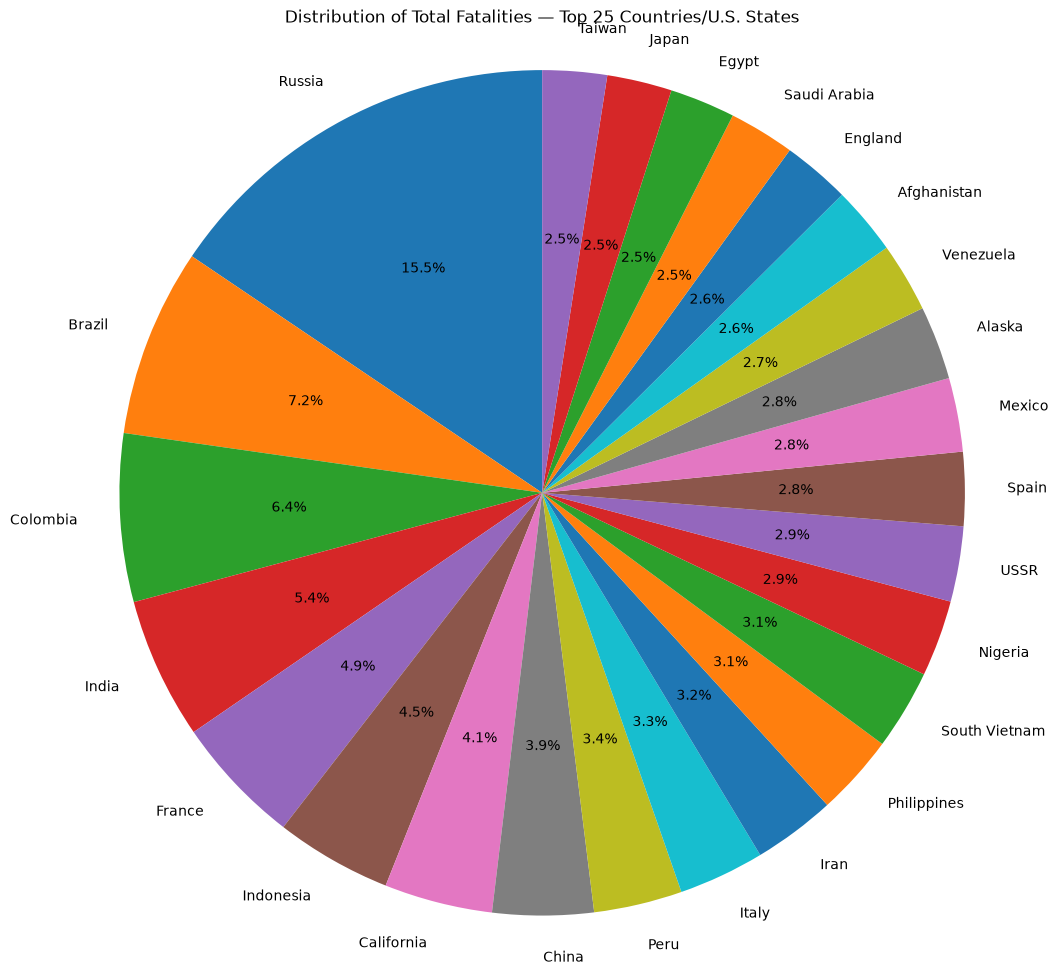

In [ ]:
# Question 10 part 2 
# We created a pie chart for the top 25 State/Country locations

plt.figure(figsize=(12, 12))

plt.pie(
    top_25.values,
    labels=top_25.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Distribution of Total Fatalities — Top 25 Countries/U.S. States"
)

plt.axis("equal")
plt.show()